# scPhyTr round trip: simulate a known model, then recover it

scPhyTr's modular pieces work in both directions. Here we **simulate** data from a tree × a
Brownian-motion trait model × a subclonal Poisson observation with *known* parameters, look at
the simulated data, then **infer** the parameters back and check we recover the truth — and that
the count model is what makes that work at low sequencing depth.

## 0. Setup

In [1]:
import os, sys
root = os.getcwd()
while root != "/" and not os.path.isdir(os.path.join(root, "src", "scphytr")):
    root = os.path.dirname(root)
sys.path[:0] = [root, os.path.join(root, "src")]; os.chdir(root)

import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import scphytr as ph
from scphytr.trait_models import BrownianMotion, OrnsteinUhlenbeck
from ete3 import Tree as ETree

# a random tree with branch lengths
rng = np.random.default_rng(0)
et = ETree(); et.populate(40, random_branches=True)
for nd in et.traverse():
    if not nd.is_root(): nd.dist = round(max(float(nd.dist), 0.1), 3)
for i, l in enumerate(et.get_leaves()): l.name = f"c{i}"
tree = ph.Tree(); tree.phylotree = et; tree.root = et.get_tree_root()
print(f"{len(et.get_leaves())} leaves")

40 leaves


## 1. Simulate — a Brownian-motion gene observed as subclonal counts

True parameters: diffusion rate $\sigma^2 = 1.0$, root mean $\mu = 0$, with **6 cells per leaf**
drawn as Poisson replicates (kept as subclonal cells, not averaged).

In [2]:
TRUE_S2, MU, N_CELLS, DEPTH = 1.0, 0.0, 6, 200.0
bm_true = BrownianMotion(tree, np.array([MU]), np.array([[TRUE_S2]]))
sim = ph.simulate(tree, bm_true, observation="subclonal", n_cells=N_CELLS,
                  mean_size=DEPTH, seed=1)
leaves = tree.root.get_leaves()
print(f"simulated {sim['counts'].shape[0]} cells over {sim['n_leaves']} leaves; "
      f"true latent range [{sim['latent'].min():.2f}, {sim['latent'].max():.2f}]")

simulated 240 cells over 40 leaves; true latent range [-1.20, 2.52]


### The simulated data

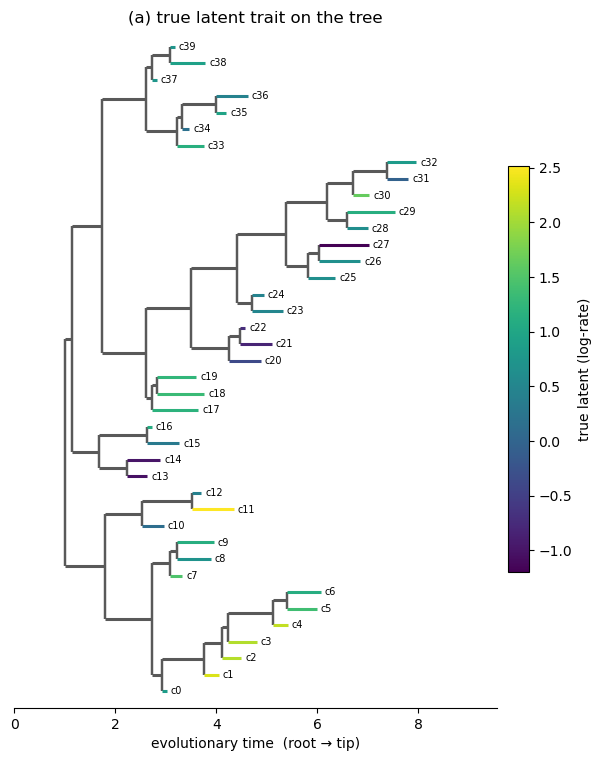

In [3]:
# (a) the tree, leaves coloured by the TRUE latent trait
node_vals = {lf: float(sim["latent"][i]) for i, lf in enumerate(leaves)}
ax = ph.pl.plot_tree(tree, node_values=node_vals, cmap="viridis",
                     cbar_label="true latent (log-rate)", title="(a) true latent trait on the tree")
plt.show()

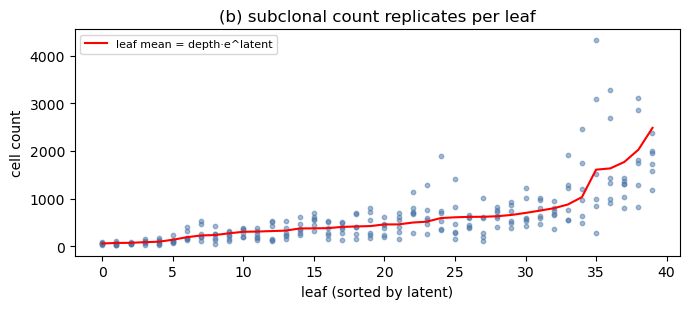

In [4]:
# (b) the subclonal counts: every cell of every leaf (Poisson replicates around exp(latent))
idx = sim["leaf_index"]; counts = sim["counts"]
order = np.argsort(sim["latent"])                      # sort leaves by latent for readability
pos = {leaf_i: rank for rank, leaf_i in enumerate(order)}
plt.figure(figsize=(7, 3.2))
plt.scatter([pos[i] for i in idx], counts, s=10, alpha=0.5, color="#4c78a8")
plt.plot(range(len(order)), DEPTH * np.exp(sim["latent"][order]), "r-", lw=1.5,
         label="leaf mean = depth·e^latent")
plt.xlabel("leaf (sorted by latent)"); plt.ylabel("cell count"); plt.legend(fontsize=8)
plt.title("(b) subclonal count replicates per leaf"); plt.tight_layout(); plt.show()

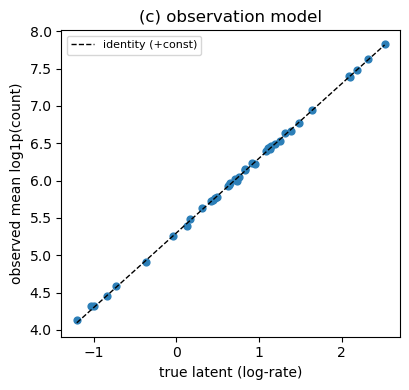

In [5]:
# (c) the observation model: per-leaf mean log1p(count) vs the true latent
import pandas as pd
ln = np.log1p(counts / sim["size_factors"])
m = pd.Series(ln).groupby(idx).mean().values
plt.figure(figsize=(4.2, 4))
plt.scatter(sim["latent"], m, s=24, color="#2c7fb8")
lo, hi = sim["latent"].min(), sim["latent"].max()
plt.plot([lo, hi], [lo + np.log(DEPTH), hi + np.log(DEPTH)], "k--", lw=1, label="identity (+const)")
plt.xlabel("true latent (log-rate)"); plt.ylabel("observed mean log1p(count)")
plt.title("(c) observation model"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. Infer — recover $\sigma^2$ with the count model

Pack the cells into an AnnData and run the scanpy-like API (`pp.setup_anndata` →
`tl.estimate_rate`); the count model keeps the cells as subclonal replicates.

In [6]:
A = ad.AnnData(X=counts[:, None])
A.var_names = ["gene0"]; A.obs["species"] = [leaves[i].name for i in idx]
A.obs["size_factors"] = sim["size_factors"]
ph.pp.setup_anndata(A, tree)
ph.tl.estimate_rate(A)
print(f"true σ² = {TRUE_S2}   ->   recovered σ̂² = {A.var.loc['gene0','rate']:.3f}")

true σ² = 1.0   ->   recovered σ̂² = 0.513


### Recovery across many genes and true values

A single gene is one noisy draw, so we simulate many genes at several true rates and check the
estimates land on the diagonal.

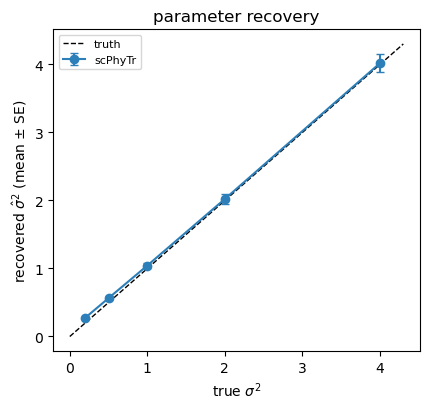

In [7]:
true_grid = [0.2, 0.5, 1.0, 2.0, 4.0]; n_genes = 40
means, ses = [], []
for s2 in true_grid:
    tms = [BrownianMotion(tree, np.array([MU]), np.array([[s2]])) for _ in range(n_genes)]
    Ag = ph.simulate_anndata(tree, tms, observation="subclonal", n_cells=N_CELLS,
                             mean_size=DEPTH, seed=100)
    ph.pp.setup_anndata(Ag, tree); ph.tl.estimate_rate(Ag)
    est = Ag.var["rate"].values
    means.append(np.mean(est)); ses.append(np.std(est) / np.sqrt(n_genes))
plt.figure(figsize=(4.4, 4.2))
plt.plot([0, 4.3], [0, 4.3], "k--", lw=1, label="truth")
plt.errorbar(true_grid, means, yerr=ses, fmt="o-", color="#2c7fb8", capsize=3, label="scPhyTr")
plt.xlabel("true $\\sigma^2$"); plt.ylabel("recovered $\\hat\\sigma^2$ (mean ± SE)")
plt.title("parameter recovery"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Why the count model: recovery vs sequencing depth

Re-observe a *fixed* set of latent realizations at decreasing depth. scPhyTr (count model) holds
the truth; the naive Gaussian-on-log pseudobulk (EvoGeneX-style) collapses when counts are sparse.

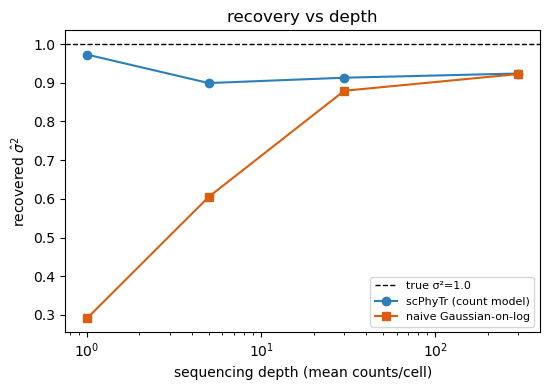

In [8]:
from scphytr.simulation import sample_latent
from scphytr.tools.model_selection import fit_bm
nL = len(leaves); n_g = 30
L = np.column_stack([np.array([sample_latent(tree, BrownianMotion(tree, np.array([MU]),
                     np.array([[TRUE_S2]])), np.random.default_rng(500 + g))[l] for l in leaves])
                     for g in range(n_g)])
depths = [1.0, 5.0, 30.0, 300.0]; sp, nv = [], []
for d in depths:
    r = np.random.default_rng(900 + int(d))
    ix = np.repeat(np.arange(nL), N_CELLS); sz = r.gamma(4, d / 4, ix.shape[0]) / d
    X = r.poisson((sz * d)[:, None] * np.exp(L[ix])).astype(float)
    Ad = ad.AnnData(X=X); Ad.var_names = [f"g{g}" for g in range(n_g)]
    Ad.obs["species"] = [leaves[i].name for i in ix]; Ad.obs["size_factors"] = sz
    ph.pp.setup_anndata(Ad, tree); ph.tl.estimate_rate(Ad)
    sp.append(np.median(Ad.var["rate"].values))
    import pandas as pd
    nvg = []
    for g in Ad.var_names:
        lc = np.log1p(Ad[:, g].X.ravel() / sz); mm = pd.Series(lc).groupby(ix).mean()
        nvg.append(fit_bm(tree, {leaves[i].name: float(mm[i]) for i in range(nL)}).params["sigma2"])
    nv.append(np.median(nvg))
plt.figure(figsize=(5.6, 4))
plt.axhline(TRUE_S2, ls="--", color="k", lw=1, label=f"true σ²={TRUE_S2}")
plt.plot(depths, sp, "o-", color="#2c7fb8", label="scPhyTr (count model)")
plt.plot(depths, nv, "s-", color="#d95f0e", label="naive Gaussian-on-log")
plt.xscale("log"); plt.xlabel("sequencing depth (mean counts/cell)")
plt.ylabel("recovered $\\hat\\sigma^2$"); plt.legend(fontsize=8)
plt.title("recovery vs depth"); plt.tight_layout(); plt.show()

## Wrap-up

The same modular components run forwards (`ph.simulate`: tree × trait model × observation model)
and backwards (`ph.tl.estimate_rate`): scPhyTr recovers the generating rate, and the count model
is what keeps that recovery honest at low sequencing depth. The full study is in
[`analysis/benchmark/simulation_study.py`](../analysis/benchmark/simulation_study.py).